In [1]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.6 MB/s eta 0:00:00


In [2]:
!pip install optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 4.3 MB/s eta 0:00:00


In [3]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [4]:
!unzip -q "HAM_CLEAN_SPLIT.zip" -d /content/dataset

In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

import optuna
from optuna.integration import TFKerasPruningCallback

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


In [6]:
CLEAN_ROOT = "/content/dataset/HAM_CLEAN_SPLIT"
TRAIN_DIR  = os.path.join(CLEAN_ROOT, "train")
VAL_DIR    = os.path.join(CLEAN_ROOT, "val")
TEST_DIR   = os.path.join(CLEAN_ROOT, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

Found 2984 files belonging to 7 classes.
Found 387 files belonging to 7 classes.
Found 390 files belonging to 7 classes.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [7]:
mixed_precision.set_global_policy("mixed_float16")

AUTOTUNE = tf.data.AUTOTUNE
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_batch(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess(x)
    return x, y

train_ds = train_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_batch,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_batch,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [ ]:
def eca_block(inputs, k_size=3):
   
    channels = inputs.shape[-1]

   
    x = layers.GlobalAveragePooling2D()(inputs)    

    
    x = layers.Reshape((channels, 1))(x)           

   
    x = layers.Conv1D(
        filters=1,
        kernel_size=k_size,
        padding="same",
        use_bias=False
    )(x)

    
    x = layers.Activation("sigmoid")(x)            

    
    x = layers.Reshape((1, 1, channels))(x)         

    
    return layers.Multiply()([inputs, x])

In [ ]:
def build_eca_model(dropout, k_size=3):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)


    x = eca_block(x, k_size=k_size)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, outputs)

In [ ]:
def objective(trial):
    tf.keras.backend.clear_session()

    lr_head = trial.suggest_float("lr_head", 3e-5, 3e-3, log=True)
    lr_ft   = trial.suggest_float("lr_ft", 1e-6, 3e-4, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.6, step=0.05)
    unfreeze_last = trial.suggest_categorical("unfreeze_last", [20,30, 40, 50,60])
    weight_decay = trial.suggest_categorical("weight_decay", [0.0, 1e-5, 1e-4])
    label_smoothing = trial.suggest_categorical("label_smoothing", [0.0, 0.05, 0.1])

    model = build_eca_model(dropout, k_size=3)

    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_head, weight_decay=weight_decay),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=6,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True),
             TFKerasPruningCallback(trial, "val_accuracy")
           
        ],
        verbose=0
    )

    
    base_model = next(
        l for l in model.layers
        if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
    )

    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_ft, weight_decay=weight_decay),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
            TFKerasPruningCallback(trial, "val_accuracy")
        ],
        verbose=0
    )

    return float(max(history.history["val_accuracy"]))


In [11]:
study_eca = optuna.create_study(direction="maximize")
study_eca.optimize(objective, n_trials=50)

print("ECA Best Validation Accuracy:", study_eca.best_value)
print("ECA Best Hyperparameters:")
for k, v in study_eca.best_params.items():
    print(k, ":", v)

[I 2026-02-27 15:12:49,409] A new study created in memory with name: no-name-75be10ea-d52b-40dc-a403-d99a46bfbd08


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 1 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 2 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported value is ignored because this `step` 3 is already reported.
  self._trial.report(float(current_score), step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/tfkeras/tfkeras.py:57: UserWarning: The reported 

ECA Best Validation Accuracy: 0.7209302186965942
ECA Best Hyperparameters:
lr_head : 0.002930491744692655
lr_ft : 8.974838008922242e-05
dropout : 0.25
unfreeze_last : 50
weight_decay : 1e-05
label_smoothing : 0.05


In [ ]:
best_params = study_eca.best_params
tf.keras.backend.clear_session()

final_model = build_eca_model(best_params["dropout"], k_size=3)
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=best_params["label_smoothing"])

ckpt_path = "mobilenetv2_eca_tuned_best.keras"

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["lr_head"],
        weight_decay=best_params["weight_decay"]
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_fe = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history_fe = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_fe,
    verbose=1
)

base_model = next(
    l for l in final_model.layers
    if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
)

base_model.trainable = True
for layer in base_model.layers[:-best_params["unfreeze_last"]]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=best_params["lr_ft"],
        weight_decay=best_params["weight_decay"]
    ),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history_ft = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.4313 - loss: 1.5391 - val_accuracy: 0.5530 - val_loss: 1.2910 - learning_rate: 0.0029
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6814 - loss: 1.0122 - val_accuracy: 0.5969 - val_loss: 1.2739 - learning_rate: 0.0029
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7227 - loss: 0.9291 - val_accuracy: 0.5866 - val_loss: 1.2729 - learning_rate: 0.0029
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7576 - loss: 0.8597 - val_accuracy: 0.5969 - val_loss: 1.2539 - learning_rate: 0.0029
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7566 - loss: 0.8376 - val_accuracy: 0.5969 - val_loss: 1.2788 - learning_rate: 0.0029
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7706 - loss: 0.8213 - val_accuracy: 0.5995 - val_loss: 1.2799 - learning_rate: 0.0029
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7865 - loss: 0.7858 - val_a

In [ ]:

best_model = keras.models.load_model(ckpt_path)
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\nECA Tuned Test Accuracy: {test_acc:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 514ms/step - accuracy: 0.6811 - loss: 1.0260

ECA Tuned Test Accuracy: 0.7000


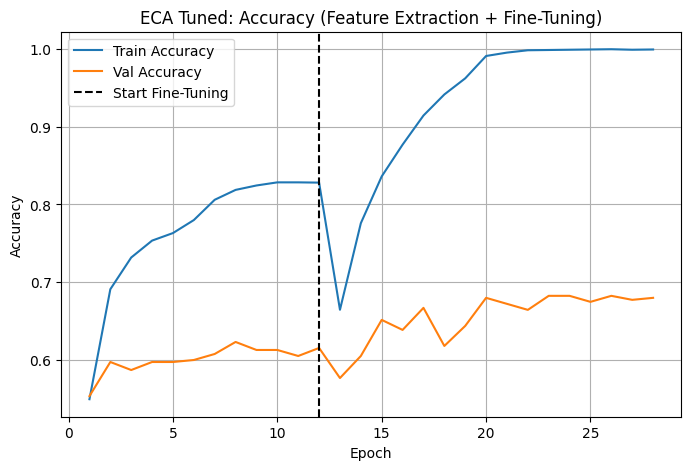

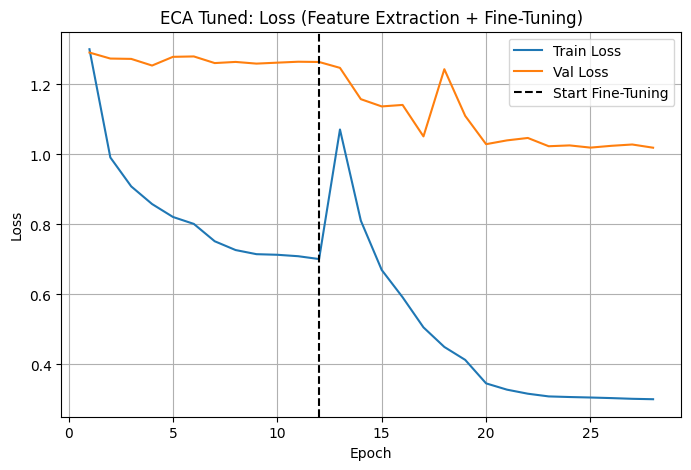

In [14]:
def combine_histories(h1, h2):
    combined = {}
    for key in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        combined[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return combined

combined = combine_histories(history_fe, history_ft)
epochs_total = range(1, len(combined["loss"]) + 1)
split_epoch = len(history_fe.history["loss"])

plt.figure(figsize=(8,5))
plt.plot(epochs_total, combined["accuracy"], label="Train Accuracy")
plt.plot(epochs_total, combined["val_accuracy"], label="Val Accuracy")
plt.axvline(split_epoch, linestyle="--", color="black", label="Start Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ECA Tuned: Accuracy (Feature Extraction + Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_total, combined["loss"], label="Train Loss")
plt.plot(epochs_total, combined["val_loss"], label="Val Loss")
plt.axvline(split_epoch, linestyle="--", color="black", label="Start Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ECA Tuned: Loss (Feature Extraction + Fine-Tuning)")
plt.legend()
plt.grid(True)
plt.show()


Macro F1: 0.7325176942185172
              precision    recall  f1-score   support

       akiec       0.60      0.58      0.59        50
         bcc       0.71      0.84      0.77        75
         bkl       0.70      0.59      0.64        75
          df       0.78      1.00      0.88        18
         mel       0.64      0.63      0.63        75
          nv       0.75      0.67      0.70        75
        vasc       0.85      1.00      0.92        22

    accuracy                           0.70       390
   macro avg       0.72      0.76      0.73       390
weighted avg       0.70      0.70      0.70       390



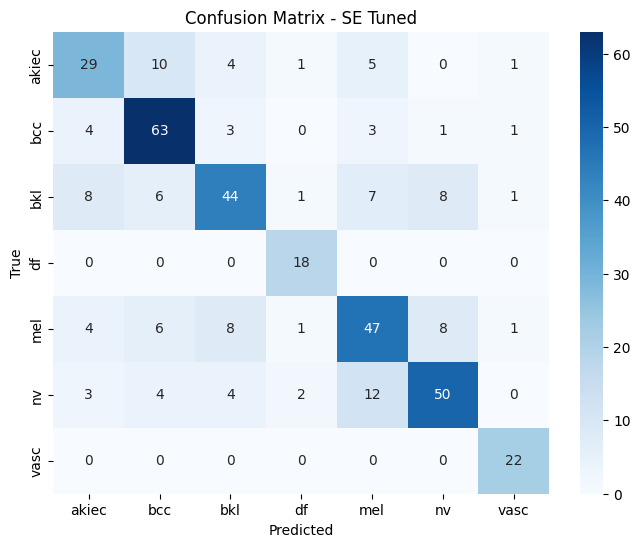

In [15]:
y_true, y_pred = [], []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - SE Tuned")
plt.show()

In [16]:
specificity = []
for i in range(len(cm)):
    tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    specificity.append(tn / (tn + fp + 1e-8))

for cls, spec in zip(class_names, specificity):
    print(f"{cls} Specificity: {spec:.4f}")

akiec Specificity: 0.9441
bcc Specificity: 0.9175
bkl Specificity: 0.9397
df Specificity: 0.9866
mel Specificity: 0.9143
nv Specificity: 0.9460
vasc Specificity: 0.9891


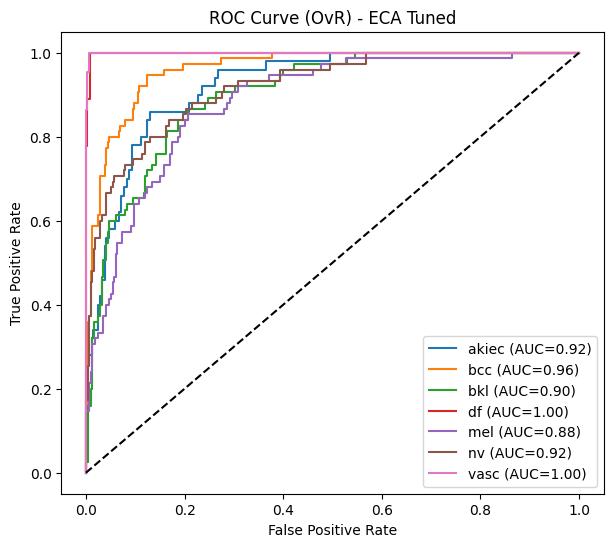

In [25]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve (OvR) - ECA Tuned")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [18]:
macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
print("Macro Average AUC:", macro_auc)


Macro Average AUC: 0.9411942038917653


In [19]:
import optuna.visualization as vis
vis.plot_param_importances(study_eca)

In [20]:
vis.plot_optimization_history(study_eca)

In [21]:
vis.plot_parallel_coordinate(study_eca)

In [22]:
best_model.save("mobilenetv2_eca_besttuned.keras")

In [23]:
best_model.save_weights("mobilenetv2_eca_besttuned.weights.h5")